# Heart Disease Risk Classifier — Model Training Walkthrough

Like `01_eda.ipynb`, this is a **thin wrapper** over the tested pipeline in `src/models/` — it reuses `build_preprocessor()`, `load_data()`, and `compute_metrics()` rather than re-implementing them. One thing this notebook deliberately does **not** do: run the full `GridSearchCV` tuning and overwrite the committed `models/final_model/` or `mlflow.db`. That authoritative run is `python src/models/train.py`, already executed, tracked in MLflow, and summarized in `report/metrics_summary.json`. This notebook shows a small, fast, in-memory cross-validation for illustration, then loads and displays the real tuned results alongside it.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from src.config import RANDOM_STATE
from src.features.build_features import build_preprocessor
from src.models.train import load_data

FIGURES_DIR = ROOT / "report" / "figures"

## 1. Load the cleaned, split data

Same stratified 80/20 split (`random_state=42`) that `train.py` uses, via the same `load_data()` function.

In [2]:
X_train, X_test, y_train, y_test = load_data()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
X_train.head()

Train: (237, 13), Test: (60, 13)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
55,54.0,124.0,266.0,109.0,2.2,1.0,4.0,0.0,2.0,1.0,2.0,1.0,7.0
159,46.0,101.0,197.0,156.0,0.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,7.0
176,43.0,130.0,315.0,162.0,1.9,1.0,3.0,0.0,0.0,0.0,1.0,1.0,3.0
86,47.0,138.0,257.0,156.0,0.0,1.0,3.0,0.0,2.0,0.0,1.0,0.0,3.0
79,58.0,150.0,270.0,111.0,0.8,1.0,4.0,0.0,2.0,1.0,1.0,0.0,7.0


## 2. Feature engineering pipeline

The same `ColumnTransformer` from `src/features/build_features.py` — `StandardScaler` on continuous features, `OneHotEncoder(drop="if_binary")` on categorical ones.

In [3]:
preprocessor = build_preprocessor()
transformed = preprocessor.fit_transform(X_train)
print(f"Input columns: {X_train.shape[1]} -> transformed columns: {transformed.shape[1]}")

Input columns: 13 -> transformed columns: 25


## 3. Illustrative cross-validation (quick, in-memory — not the tuned run)

5-fold stratified CV with each model's *default* hyperparameters, purely to see the pipeline work end-to-end in a few seconds. Nothing here is saved to MLflow or disk.

In [4]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
quick_results = {}

for name, estimator in [
    ("logistic_regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("random_forest", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("xgboost", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
]:
    pipeline = Pipeline([("preprocessor", build_preprocessor()), ("classifier", estimator)])
    cv_result = cross_validate(pipeline, X_train, y_train, cv=5, scoring=scoring)
    quick_results[name] = {m: cv_result[f"test_{m}"].mean() for m in scoring}

pd.DataFrame(quick_results).T.round(3)

,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.843,0.856,0.797,0.821,0.900
random_forest,0.797,0.785,0.769,0.774,0.901
xgboost,0.801,0.778,0.788,0.781,0.882


## 4. Authoritative results (`python src/models/train.py`, full `GridSearchCV`)

These are the real, tuned, MLflow-tracked numbers reported in `report/report.md` — loaded here from `report/metrics_summary.json` rather than re-computed.

In [5]:
summary_path = ROOT / "report" / "metrics_summary.json"
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    print(f"Best model: {summary['best_model']}\n")
    rows = {
        name: {"cv_roc_auc_mean": r["cv_roc_auc_mean"], **r["test_metrics"]}
        for name, r in summary["models"].items()
    }
    display(pd.DataFrame(rows).T.round(4))
else:
    print(f"{summary_path} not found — run `python src/models/train.py` first.")

Best model: random_forest



,cv_roc_auc_mean,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.9021,0.8167,0.8696,0.7143,0.7843,0.9375
random_forest,0.9056,0.8500,0.8800,0.7857,0.8302,0.9431
xgboost,0.8868,0.8167,0.8696,0.7143,0.7843,0.9208


## 5. Best model's evaluation plots

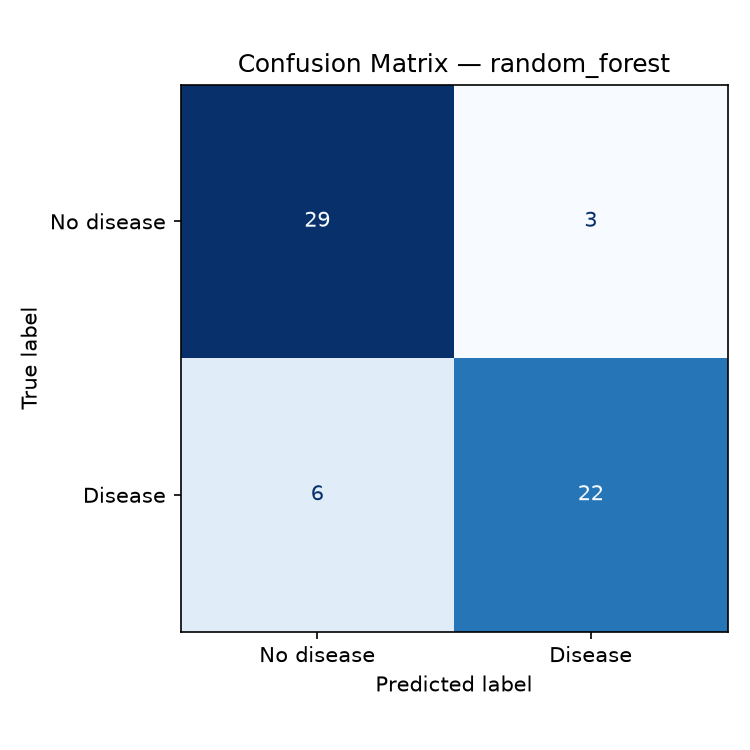

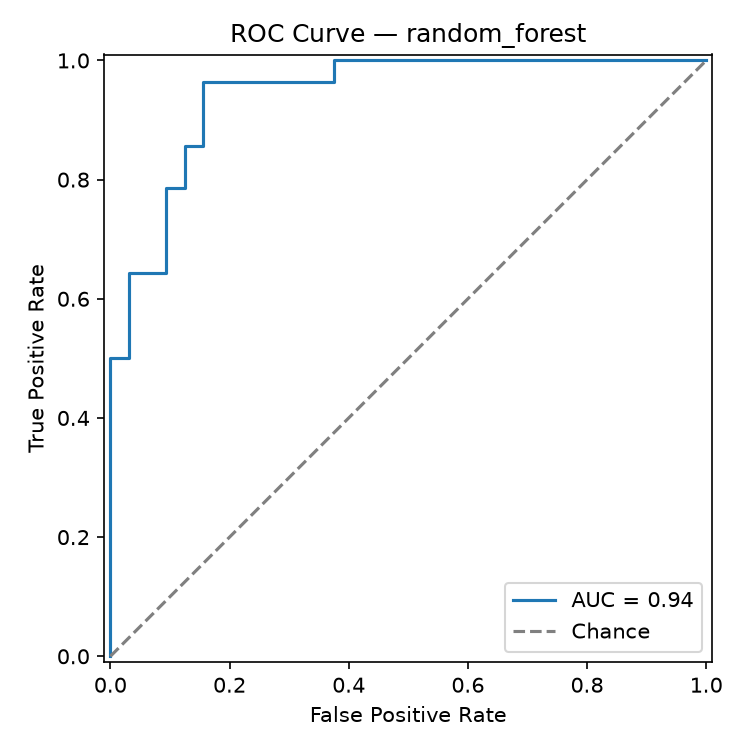

In [6]:
cm_path = FIGURES_DIR / "confusion_matrix_random_forest.png"
roc_path = FIGURES_DIR / "roc_curve_random_forest.png"
if cm_path.exists() and roc_path.exists():
    display(Image(filename=cm_path))
    display(Image(filename=roc_path))
else:
    print("Run `python src/models/train.py` first to generate these plots.")

## 6. MLflow experiment tracking (read-only query)

Lists the tracked runs without starting any new ones — same tracking store `mlflow ui --backend-store-uri sqlite:///mlflow.db` reads from.

In [7]:
mlflow_db_path = ROOT / "mlflow.db"
if mlflow_db_path.exists():
    import mlflow

    mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path}")
    runs = mlflow.search_runs(experiment_names=["heart-disease-classification"])
    metric_cols = [c for c in runs.columns if c.startswith("metrics.test_")]
    display(runs[["tags.mlflow.runName", *metric_cols]].round(4))
else:
    print(f"{mlflow_db_path} not found — run `python src/models/train.py` first.")

,tags.mlflow.runName,metrics.test_precision,metrics.test_accuracy,metrics.test_recall,metrics.test_f1,metrics.test_roc_auc
0,xgboost,0.8696,0.8167,0.7143,0.7843,0.9208
1,random_forest,0.8800,0.8500,0.7857,0.8302,0.9431
2,logistic_regression,0.8696,0.8167,0.7143,0.7843,0.9375


## 7. Load the packaged final model and predict

Same `load_model()` / `predict_one()` helpers the FastAPI app (`api/main.py`) uses — one code path for both.

In [8]:
from src.models.predict import load_model, predict_one

model = load_model()
sample = X_test.iloc[0].to_dict()
prediction, confidence = predict_one(model, sample)
actual = y_test.iloc[0]

print(f"Patient features: {sample}")
print(f"Predicted: {prediction} (confidence={confidence:.3f}), Actual: {actual}")

Patient features: {'age': 41.0, 'trestbps': 120.0, 'chol': 157.0, 'thalach': 182.0, 'oldpeak': 0.0, 'sex': 1.0, 'cp': 2.0, 'fbs': 0.0, 'restecg': 0.0, 'exang': 0.0, 'slope': 1.0, 'ca': 0.0, 'thal': 3.0}
Predicted: 0 (confidence=0.984), Actual: 0


## Next step

Serving (`api/main.py`), containerization (`Dockerfile`), Kubernetes deployment (`k8s/`), and monitoring (`docker-compose.yml`) are covered in `report/report.md`, not in notebook form — those are inherently CLI/infrastructure steps rather than exploratory ones.